In [1]:
# Library dasar untuk data dan matematika
import numpy as np
import pandas as pd

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library machine learning dari scikit-learn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

In [42]:
# Memuat dataset Iris
iris = load_iris()
X = iris.data      # fitur: panjang & lebar kelopak, panjang & lebar mahkota
y = iris.target    # label: 0 = setosa, 1 = versicolor, 2 = virginica

# Melihat nama fitur dan label
print("Nama fitur:", iris.feature_names)
print("Nama kelas:", iris.target_names)
print("Jumlah sampel:", len(X))

Nama fitur: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nama kelas: ['setosa' 'versicolor' 'virginica']
Jumlah sampel: 150


In [43]:
# Ubah ke DataFrame agar lebih mudah dibaca
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

# Tampilkan 5 baris pertama
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [44]:
# Statistik ringkas
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


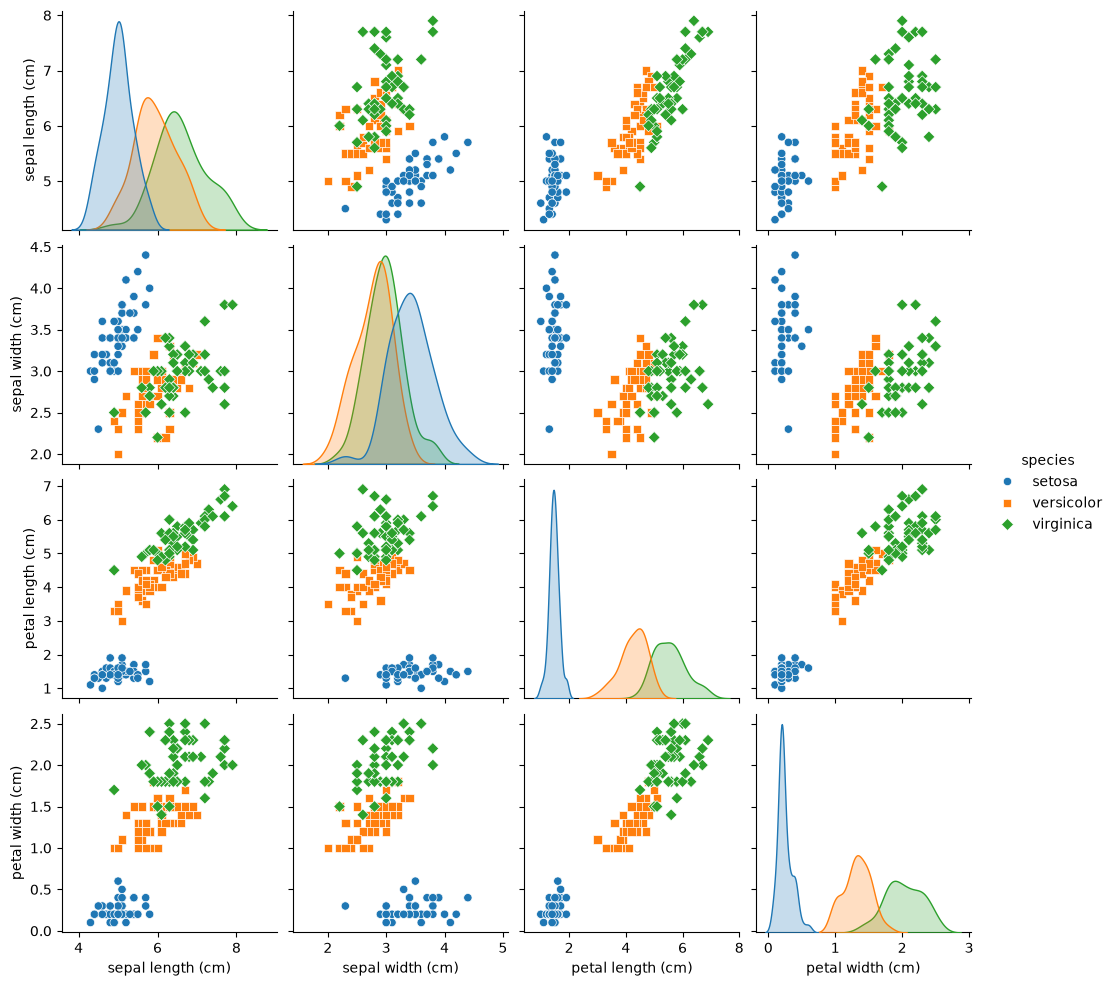

In [45]:
# Visualisasi sebaran fitur
sns.pairplot(df, hue='species', markers=['o','s','D'])
plt.show()

In [46]:
# Split 80% untuk training, 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data latih:", X_train.shape[0], "sampel")
print("Data uji  :", X_test.shape[0], "sampel")

Data latih: 120 sampel
Data uji  : 30 sampel


In [54]:
# Membuat model KNN dengan k=3 (melihat 3 tetangga terdekat)
model = KNeighborsClassifier(n_neighbors=10)

In [55]:
# Latih model dengan data latih
model.fit(X_train, y_train)
print("Model selesai dilatih!")

Model selesai dilatih!


In [56]:
# Prediksi kelas untuk data uji
y_pred = model.predict(X_test)

# Lihat 10 prediksi pertama
print("Prediksi   :", y_pred[:10])
print("Nilai asli :", y_test[:10])

Prediksi   : [1 0 2 1 1 0 1 2 1 1]
Nilai asli : [1 0 2 1 1 0 1 2 1 1]


In [57]:
# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi: {akurasi*100:.2f}%")

Akurasi: 100.00%


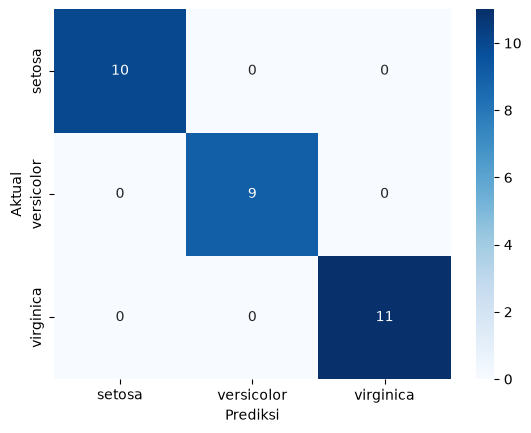

In [51]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, xticklabels=iris.target_names, yticklabels=iris.target_names, cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [52]:
# Laporan lengkap
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [53]:
# Misal kita dapat bunga baru dengan ukuran:
bunga_baru = [[5.1, 3.5, 1.4, 0.2]]  # sepal length, sepal width, petal length, petal width

prediksi = model.predict(bunga_baru)
print("Prediksi spesies:", iris.target_names[prediksi][0])

Prediksi spesies: setosa
